Frailty_analysis




importing the dependencies

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_validate, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                            cohen_kappa_score, roc_auc_score, make_scorer)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import xgboost as xgb
import warnings
import pickle
warnings.filterwarnings('ignore')



data collection and processing

In [39]:
df=pd.read_csv('/content/spare data clean 2 (1).csv')
print("Columns in DataFrame after loading:", df.columns.tolist())

Columns in DataFrame after loading: ['clinical_visit', 'gender', 'age', 'ortho_hypotension', 'V1', 'V2', 'weight_loss', 'exhaustion_score', 'raise_chair_time', 'gait_get_up', 'gait_speed_slower', 'bmi_score', 'bmi_body_fat', 'waist', 'lean_body_mass', 'cognitive_total_score', 'memory_complain', 'S1', 'S2', 'mmse_total_score', 'depression_total_score', 'anxiety_perception', 'social_calls', 'social_phone', 'life_quality', 'pain_perception', 'sm1', 'sm2', 'alcohol_units', 'katz_index', 'iadl_grade', 'comorbidities_count', 'medication_count', 'fried']


In [40]:
#print first 5 rows of the dataset
df.head()

,clinical_visit,gender,age,ortho_hypotension,V1,V2,weight_loss,exhaustion_score,raise_chair_time,gait_get_up,...,life_quality,pain_perception,sm1,sm2,alcohol_units,katz_index,iadl_grade,comorbidities_count,medication_count,fried
0,1,0,78,0,0,0,0,1,14.00,9.05,...,6.8,1.2,0,1,1.5,6.0,29,6,5,0
1,2,0,79,0,0,0,0,1,13.46,10.30,...,7.2,1.0,0,1,0.0,6.0,25,7,6,0
2,3,0,79,0,0,0,0,1,13.40,9.40,...,6.5,1.3,0,1,0.0,6.0,24,7,6,0
3,4,0,80,0,0,0,0,1,14.10,9.20,...,6.9,2.5,0,1,0.0,6.0,26,8,7,0
4,3,1,73,0,0,0,0,1,15.70,10.40,...,7.8,2.4,0,1,0.0,6.0,30,11,10,1


In [41]:
#number of rows and columns in the dataset
df.shape

(123, 34)

In [42]:
#getting some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   clinical_visit          123 non-null    int64  
 1   gender                  123 non-null    int64  
 2   age                     123 non-null    int64  
 3   ortho_hypotension       123 non-null    int64  
 4   V1                      123 non-null    int64  
 5   V2                      123 non-null    int64  
 6   weight_loss             123 non-null    int64  
 7   exhaustion_score        123 non-null    int64  
 8   raise_chair_time        123 non-null    float64
 9   gait_get_up             123 non-null    float64
 10  gait_speed_slower       123 non-null    int64  
 11  bmi_score               123 non-null    float64
 12  bmi_body_fat            123 non-null    float64
 13  waist                   123 non-null    float64
 14  lean_body_mass          123 non-null    fl

In [43]:
#statistical measure about the data
df.describe()

,clinical_visit,gender,age,ortho_hypotension,V1,V2,weight_loss,exhaustion_score,raise_chair_time,gait_get_up,...,life_quality,pain_perception,sm1,sm2,alcohol_units,katz_index,iadl_grade,comorbidities_count,medication_count,fried
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,...,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000
mean,2.406504,0.439024,76.390244,0.040650,0.065041,0.666667,0.056911,1.243902,11.507073,9.400000,...,8.682114,2.163415,0.552846,0.382114,0.764228,5.979675,28.000000,4.056911,4.471545,0.878049
std,1.115005,0.498298,4.429103,0.198287,0.247606,0.473333,0.232619,0.431191,2.514049,2.932784,...,1.208375,1.803970,0.499233,0.487892,1.109433,0.099143,3.454624,2.875278,3.113496,0.805568
min,1.000000,0.000000,61.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.900000,4.000000,...,5.000000,0.000000,0.000000,0.000000,0.000000,5.500000,19.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,74.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.820000,7.510000,...,8.000000,1.000000,0.000000,0.000000,0.000000,6.000000,25.000000,2.000000,2.000000,0.000000
50%,2.000000,0.000000,77.000000,0.000000,0.000000,1.000000,0.000000,1.000000,11.150000,9.000000,...,8.600000,1.800000,1.000000,0.000000,0.000000,6.000000,30.000000,4.000000,4.000000,1.000000
75%,3.000000,1.000000,79.000000,0.000000,0.000000,1.000000,0.000000,1.000000,13.400000,10.950000,...,10.000000,3.000000,1.000000,1.000000,1.000000,6.000000,31.000000,6.000000,6.000000,2.000000
max,4.000000,1.000000,86.000000,1.000000,1.000000,1.000000,1.000000,2.000000,19.200000,18.300000,...,10.000000,7.000000,1.000000,1.000000,5.000000,6.000000,31.000000,12.000000,13.000000,2.000000


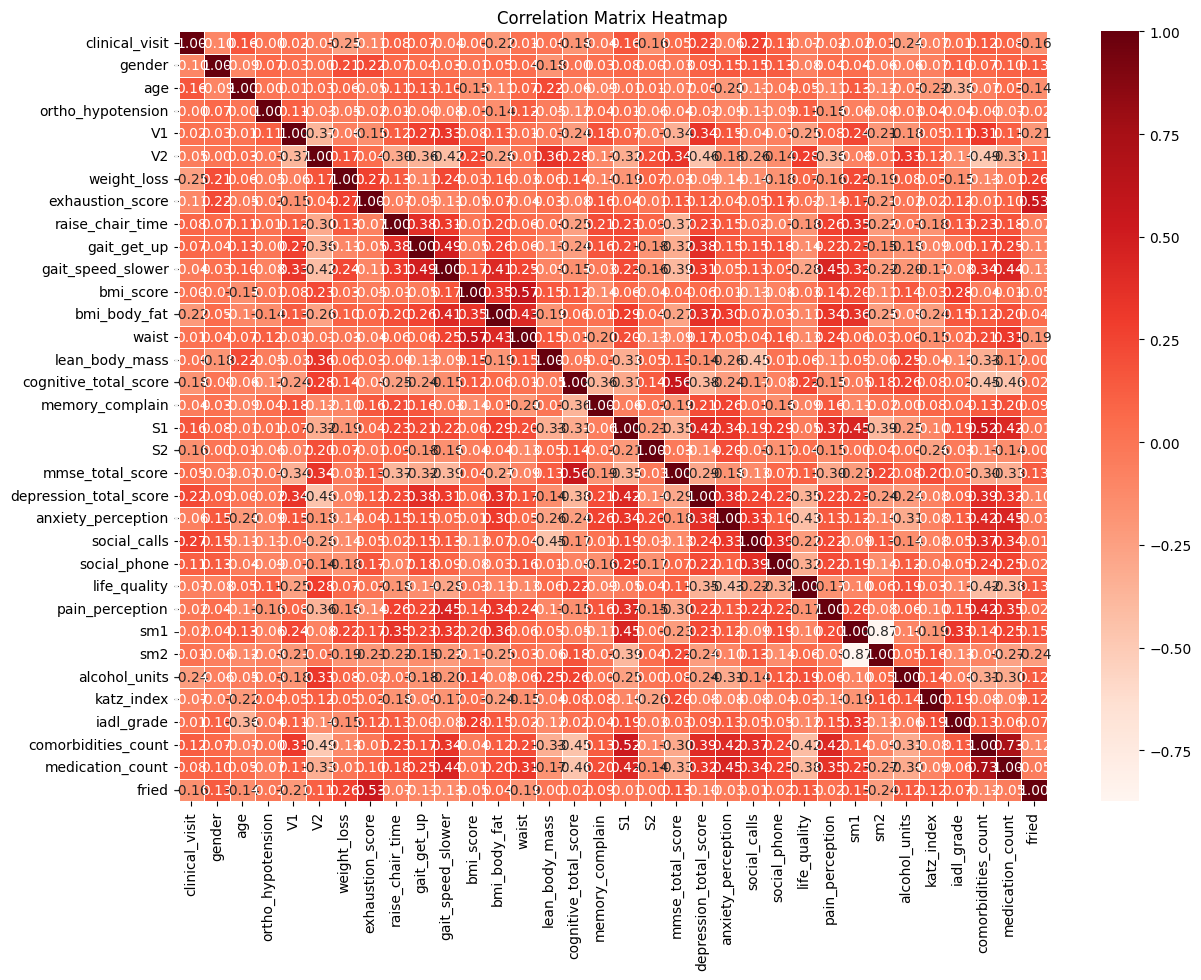

In [44]:
# Calculate correlation matrix
corr =df.corr()

# Set plot size
plt.figure(figsize=(14, 10))

# Plot heatmap
sns.heatmap(corr,
            annot=True,        # show values in cells
            cmap='Reds',       # similar red color theme
            linewidths=0.5,    # grid lines
            fmt=".2f")         # number format

plt.title("Correlation Matrix Heatmap")
plt.show()

In [45]:
#checking the disttribution of target variable
df['fried'].value_counts()

,count
fried,
0,48
1,42
2,33


1-->defective heart

0-->healthy heart

splitting the features and target

In [156]:
x=df[['V1','weight_loss', 'exhaustion_score', 'sm2','memory_complain','ortho_hypotension','medication_count','age','V2','sm1','pain_perception','depression_total_score','anxiety_perception']]
y=df['fried']

In [79]:
#x=df.drop(columns='fried',axis=1)
#y=df['fried']

In [157]:
print(x)

     V1  weight_loss  exhaustion_score  sm2  memory_complain  \
0     0            0                 1    1                0   
1     0            0                 1    1                0   
2     0            0                 1    1                0   
3     0            0                 1    1                0   
4     0            0                 1    1                0   
..   ..          ...               ...  ...              ...   
118   0            1                 1    0                0   
119   0            1                 1    0                0   
120   0            1                 2    0                0   
121   0            0                 2    1                1   
122   0            0                 1    1                0   

     ortho_hypotension  medication_count  age  V2  sm1  pain_perception  \
0                    0                 5   78   0    0              1.2   
1                    0                 6   79   0    0              1.0   
2     

In [158]:
print(y)

0      0
1      0
2      0
3      0
4      1
      ..
118    2
119    2
120    1
121    2
122    2
Name: fried, Length: 123, dtype: int64


splitting the data into training data and test data

In [159]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

In [160]:
from imblearn.over_sampling import SMOTE

sampling_strategy = {
    0: 450,
    1: 500,
    2: 470   # adjust based on your classes
}

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)

X_resampled, y_resampled = smote.fit_resample(x, y)

df_smote = pd.concat([
    pd.DataFrame(X_resampled, columns=x.columns),
    pd.Series(y_resampled, name='target')
], axis=1)

print("After SMOTE:", df_smote.shape)
print(df_smote['target'].value_counts())


After SMOTE: (1420, 15)
target
1    500
2    470
0    450
Name: count, dtype: int64


In [161]:
x_train, y_train = smote.fit_resample(x_train, y_train)

In [162]:
print(x.shape,x_train.shape,x_test.shape)

(123, 14) (1420, 14) (25, 14)


Logistic Regression

model traning

In [163]:
model1 = LogisticRegression(max_iter=300)

#training the logistic regression model with training data
model1.fit(x_train, y_train)


LogisticRegression(max_iter=300)

model evaluation

accuracy score

In [164]:
#accuracy on training data
x_train_prediction=model1.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [165]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.7049295774647887


In [166]:
#accuracy on test data
x_test_prediction=model1.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [167]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.68


confusion matrix





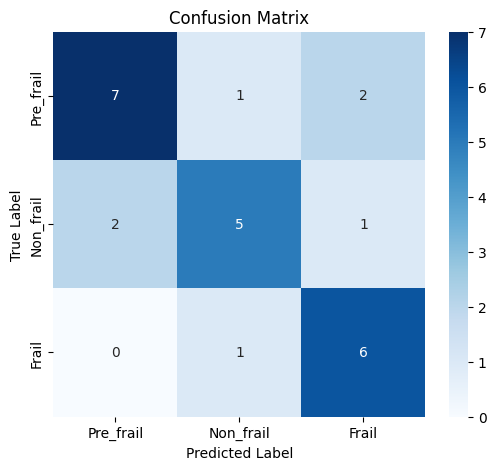

              precision    recall  f1-score   support

   Pre_frail       0.78      0.70      0.74        10
   Non_frail       0.71      0.62      0.67         8
       Frail       0.67      0.86      0.75         7

    accuracy                           0.72        25
   macro avg       0.72      0.73      0.72        25
weighted avg       0.73      0.72      0.72        25



In [142]:
y_pred = model1.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names using the labels from LabelEncoder
# The correct labels are in y_labels from the earlier execution of R1IX09zRPQFl
class_names = ['Pre_frail', 'Non_frail', 'Frail'] # Manually defined to match the original df['fried'] mapping (0,1,2)
# Or, if y_labels is directly accessible and ordered correctly from the last execution:
# class_names = y_labels

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

**XGBOOST**

model training

In [168]:
model2=xgb.XGBClassifier()

In [169]:
model2.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

model evaluation

accuracy score

In [170]:
#accuracy on training data
x_train_prediction=model2.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)

In [171]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 1.0


In [172]:
#accuracy on test data
x_test_prediction=model2.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)

In [173]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.6


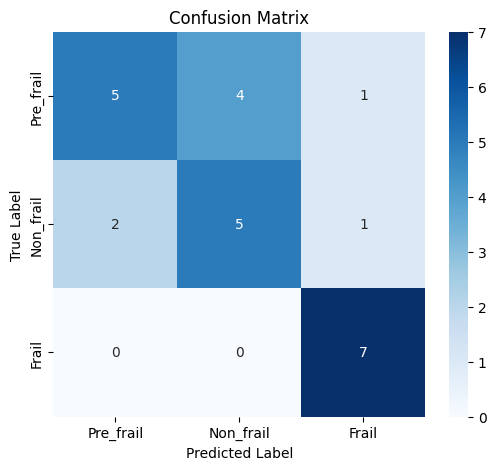

              precision    recall  f1-score   support

   Pre_frail       0.71      0.50      0.59        10
   Non_frail       0.56      0.62      0.59         8
       Frail       0.78      1.00      0.88         7

    accuracy                           0.68        25
   macro avg       0.68      0.71      0.68        25
weighted avg       0.68      0.68      0.67        25



In [149]:
y_pred = model2.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names using the labels from LabelEncoder
# The correct labels are in y_labels from the earlier execution of R1IX09zRPQFl
class_names = ['Pre_frail', 'Non_frail', 'Frail'] # Manually defined to match the original df['fried'] mapping (0,1,2)
# Or, if y_labels is directly accessible and ordered correctly from the last execution:
# class_names = y_labels

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

In [174]:
from sklearn.ensemble import RandomForestClassifier

model3= RandomForestClassifier(
    max_depth=8,        # limit tree depth
    min_samples_leaf=5 # prevent overfitting
)


model evaluation

accuracy score


In [175]:

model3.fit(x_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5)

In [176]:
#accuracy on training data
x_train_prediction=model3.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)

In [177]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.9661971830985916


In [178]:
#accuracy on test data
x_test_prediction=model3.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)

In [180]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.64


confusion matrix

In [ ]:






print(f"\nFried outcome summary:\n{df['fried'].value_counts()}")

# ---------------------------
# 2. Clean and prepare outcome labels
# ---------------------------
# Map outcome to descriptive labels
df['fried'] = df['fried'].map({0: 'Pre_frail', 1: 'Non_frail', 2: 'Frail'})
print(f"\nFried distribution:\n{df['fried'].value_counts(normalize=True)}")

# ---------------------------
# 3. Variable typing
# ---------------------------
# Separate predictors from outcome
predictor_names = [col for col in df.columns if col != 'fried']

# Identify binary variables (2 unique values)
binary_vars = [col for col in predictor_names if df[col].nunique() == 2]
print(f"\nBinary vars (2 unique values): {binary_vars}")

# Identify small categorical variables (<=6 unique values, excluding binary)
small_cat_vars = [col for col in predictor_names
                  if df[col].nunique() <= 6 and col not in binary_vars]
print(f"\nSmall categorical vars (<=6 levels): {small_cat_vars}")

# Identify continuous numeric variables (>10 unique values)
numeric_vars = [col for col in predictor_names
                if df[col].nunique() > 10 and pd.api.types.is_numeric_dtype(df[col])]
print(f"\nNumeric vars (continuous-like): {numeric_vars}")

# Convert binary and categorical to category dtype
for col in binary_vars + small_cat_vars:
    df[col] = df[col].astype('category')

# ---------------------------
# 4. EDA (Exploratory Data Analysis)
# ---------------------------
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Frequency of outcome
print(f"\nOutcome proportions:\n{df['fried'].value_counts(normalize=True)}")

# Boxplot for age if present
if 'age' in df.columns:
    plt.figure(figsize=(8, 6))
    df.boxplot(column='age', by='fried')
    plt.title('Age by Frailty Status')
    plt.suptitle('')
    plt.ylabel('Age')
    plt.tight_layout()
    plt.savefig('age_by_frailty.png', dpi=300, bbox_inches='tight')
    plt.show()

# Chi-square tests for categorical predictors
print("\n" + "-"*50)
print("Chi-square tests for categorical predictors:")
print("-"*50)
cat_results = []
categorical_predictors = binary_vars + small_cat_vars

for var in categorical_predictors:
    contingency_table = pd.crosstab(df[var], df['fried'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    cat_results.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof
    })
    print(f"{var}: χ² = {chi2:.4f}, p = {p_value:.4f}")

cat_results_df = pd.DataFrame(cat_results)

# Kruskal-Wallis tests for numeric predictors
print("\n" + "-"*50)
print("Kruskal-Wallis tests for numeric predictors:")
print("-"*50)
num_results = []

for var in numeric_vars:
    groups = [df[df['fried'] == label][var].dropna() for label in df['fried'].unique()]
    h_stat, p_value = stats.kruskal(*groups)
    num_results.append({
        'variable': var,
        'H_statistic': h_stat,
        'p_value': p_value
    })
    print(f"{var}: H = {h_stat:.4f}, p = {p_value:.4f}")

num_results_df = pd.DataFrame(num_results)

# ---------------------------
# 5. Prepare data for modeling
# ---------------------------
# Encode outcome variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['fried'])
y_labels = label_encoder.classes_

# Prepare feature matrix
# Convert categorical variables to dummy variables
X = pd.get_dummies(df[predictor_names], drop_first=True)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classes: {y_labels}")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2025, stratify=y
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# 6. Models (multinomial classification)
# ---------------------------
print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

# Define cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2025)

models = {}
cv_results = {}

# 6.1 Multinomial Logistic Regression
print("\n1. Training Multinomial Logistic Regression...")
models['multinom'] = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=2025
)
models['multinom'].fit(X_train_scaled, y_train)
cv_scores = cross_validate(models['multinom'], X_train_scaled, y_train,
                           cv=cv, scoring='accuracy', return_train_score=True)
cv_results['multinom'] = cv_scores
print(f"CV Accuracy: {cv_scores['test_score'].mean():.4f} (+/- {cv_scores['test_score'].std():.4f})")

# 6.2 LASSO Multinomial (L1 regularization with CV)
print("\n2. Training LASSO Multinomial Logistic Regression...")
models['lasso'] = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    max_iter=1000,
    random_state=2025,
    n_jobs=-1
)
models['lasso'].fit(X_train_scaled, y_train)
print(f"Best C value: {models['lasso'].C_[0]:.6f}")

# Extract non-zero coefficients
coef_df = pd.DataFrame(
    models['lasso'].coef_,
    columns=X.columns,
    index=y_labels
)
print("\nNon-zero coefficients (top 10 by absolute value):")
for class_label in y_labels:
    print(f"\n{class_label}:")
    class_coefs = coef_df.loc[class_label]
    non_zero = class_coefs[class_coefs != 0].abs().sort_values(ascending=False)
    print(non_zero.head(10))

# 6.3 Random Forest
print("\n3. Training Random Forest...")
models['rf'] = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=2025,
    n_jobs=-1
)
models['rf'].fit(X_train_scaled, y_train)
cv_scores = cross_validate(models['rf'], X_train_scaled, y_train,
                           cv=cv, scoring='accuracy', return_train_score=True)
cv_results['rf'] = cv_scores
print(f"CV Accuracy: {cv_scores['test_score'].mean():.4f} (+/- {cv_scores['test_score'].std():.4f})")

# 6.4 XGBoost
print("\n4. Training XGBoost...")
models['xgb'] = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_labels),
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=2025,
    eval_metric='mlogloss'
)
models['xgb'].fit(X_train_scaled, y_train)
cv_scores = cross_validate(models['xgb'], X_train_scaled, y_train,
                           cv=cv, scoring='accuracy', return_train_score=True)
cv_results['xgb'] = cv_scores
print(f"CV Accuracy: {cv_scores['test_score'].mean():.4f} (+/- {cv_scores['test_score'].std():.4f})")

# 6.5 SVM (radial basis function)
print("\n5. Training SVM (RBF kernel)...")
models['svm'] = SVC(
    kernel='rbf',
    probability=True,
    random_state=2025
)
models['svm'].fit(X_train_scaled, y_train)
cv_scores = cross_validate(models['svm'], X_train_scaled, y_train,
                           cv=cv, scoring='accuracy', return_train_score=True)
cv_results['svm'] = cv_scores
print(f"CV Accuracy: {cv_scores['test_score'].mean():.4f} (+/- {cv_scores['test_score'].std():.4f})")

# ---------------------------
# 7. Model comparison & test evaluation
# ---------------------------
print("\n" + "="*50)
print("MODEL EVALUATION ON TEST SET")
print("="*50)

eval_results = {}

for name, model in models.items():
    print(f"\n{name.upper()}:")
    print("-" * 40)

    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=y_labels, columns=y_labels)
    print(cm_df)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=y_labels))

    eval_results[name] = {
        'accuracy': accuracy,
        'kappa': kappa,
        'confusion_matrix': cm
    }

# Compare CV results
print("\n" + "="*50)
print("CROSS-VALIDATION COMPARISON")
print("="*50)
cv_comparison = pd.DataFrame({
    name: {
        'Mean CV Accuracy': scores['test_score'].mean(),
        'Std CV Accuracy': scores['test_score'].std()
    }
    for name, scores in cv_results.items()
}).T
print(cv_comparison)

# Variable importance for tree-based models
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

# Random Forest importance
print("\nRandom Forest - Top 15 features:")
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': models['rf'].feature_importances_
}).sort_values('importance', ascending=False)
print(rf_importance.head(15))

# XGBoost importance
print("\nXGBoost - Top 15 features:")
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': models['xgb'].feature_importances_
}).sort_values('importance', ascending=False)
print(xgb_importance.head(15))

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importance.head(15).plot(x='feature', y='importance', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Random Forest - Top 15 Features')
axes[0].set_xlabel('Importance')

xgb_importance.head(15).plot(x='feature', y='importance', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('XGBoost - Top 15 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------
# 8. Clustering & dimensionality reduction
# ---------------------------
print("\n" + "="*50)
print("CLUSTERING & DIMENSIONALITY REDUCTION")
print("="*50)

# Work with numeric variables only
if len(numeric_vars) > 0:
    num_df = df[numeric_vars].copy()
    num_df_scaled = StandardScaler().fit_transform(num_df)

    # PCA
    print("\nPCA Analysis:")
    pca = PCA()
    pca_result = pca.fit_transform(num_df_scaled)

    print(f"Explained variance ratio (first 5 components):")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"PC{i+1}: {var:.4f}")

    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components_95 = np.argmax(cumsum >= 0.95) + 1
    print(f"\nComponents needed for 95% variance: {n_components_95}")

    # t-SNE
    print("\nComputing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=15, random_state=2025)
    tsne_result = tsne.fit_transform(num_df_scaled)

    # Plot t-SNE
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1],
                         c=y, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Frailty Class')
    plt.title('t-SNE Visualization by Frailty Status')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.savefig('tsne_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    # K-means clustering
    print("\nK-means Clustering (k=3):")
    kmeans = KMeans(n_clusters=3, random_state=2025, n_init=50)
    clusters = kmeans.fit_predict(num_df_scaled)

    # Cross-tabulation of clusters vs. frailty
    cluster_vs_frailty = pd.crosstab(
        clusters,
        df['fried'],
        rownames=['Cluster'],
        colnames=['Frailty']
    )
    print(cluster_vs_frailty)

# ---------------------------
# 9. Save models and outputs
# ---------------------------
print("\n" + "="*50)
print("SAVING RESULTS")
print("="*50)

# Save models
with open('frailty_models_multinomial.pkl', 'wb') as f:
    pickle.dump(models, f)
print("Models saved to: frailty_models_multinomial.pkl")

# Save scaler and label encoder
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save test results
if len(cat_results) > 0:
    cat_results_df.to_csv('categorical_tests.csv', index=False)
    print("Categorical tests saved to: categorical_tests.csv")

if len(num_results) > 0:
    num_results_df.to_csv('numeric_tests.csv', index=False)
    print("Numeric tests saved to: numeric_tests.csv")

# Save feature importance
rf_importance.to_csv('rf_feature_importance.csv', index=False)
xgb_importance.to_csv('xgb_feature_importance.csv', index=False)
print("Feature importance saved to CSV files")

# Save evaluation results
eval_df = pd.DataFrame(eval_results).T
eval_df.to_csv('model_evaluation.csv')
print("Model evaluation saved to: model_evaluation.csv")

# ---------------------------
# 10. Notes & recommendations
# ---------------------------
print("\n" + "="*50)
print("NOTES & RECOMMENDATIONS")
print("="*50)
print("""
- Outcome 'fried' modeled as multinomial with labels: Pre_frail, Non_frail, Frail
- Dataset is relatively small (n=123): results should be interpreted with caution
- Used repeated stratified k-fold cross-validation (5 folds × 3 repeats)
- Consider class rebalancing if class imbalance significantly impacts performance
- LASSO identified most important predictors through feature selection
- Tree-based models (RF, XGBoost) provide feature importance rankings
- t-SNE visualization can help understand class separability
- For deployment, use saved models with the scaler and label encoder
""")

print("\nAnalysis complete!")